In [1]:
import torch
torch.set_default_dtype(torch.float64)
from RBF_code import *

## Ideal distribution of nodes

From our analysis of the RBF interpolation we have observed that both the distribution of nodes and $\epsilon$ have an influence on the quality of the interpolation. One could maybe derive an analytical ideal set of values, but could also use existing optimization algorithms. We have here implemented a gradiend descent algorithm with backtracking with armijo conditions with $\mathcal c = 1/2$. We have a parameter $\mathcal L$ (That can be interpreted as the Lipshictz estimate, but this is outside the scope) that we initialize and update troughout the algorithm. How this is updated is something we will look into more later in the project.

The function we try to minimize is 
$$C(\mathbf{x},\epsilon) = \frac{b-a}{N}\sum_{k=0}^{N}\Big(f(\eta_k)-\tilde{f}(\eta_k)\Big)^{2}$$

where $\tilde{f}$ is the RBF interpolation we have discussed previously.

L=1: cost 5.984e-02 -> 3.182e-06, eps: 2.0 -> 1.3016
L=10: cost 5.984e-02 -> 3.572e-05, eps: 2.0 -> 1.3673
L=100: cost 5.984e-02 -> 1.114e-03, eps: 2.0 -> 1.5763


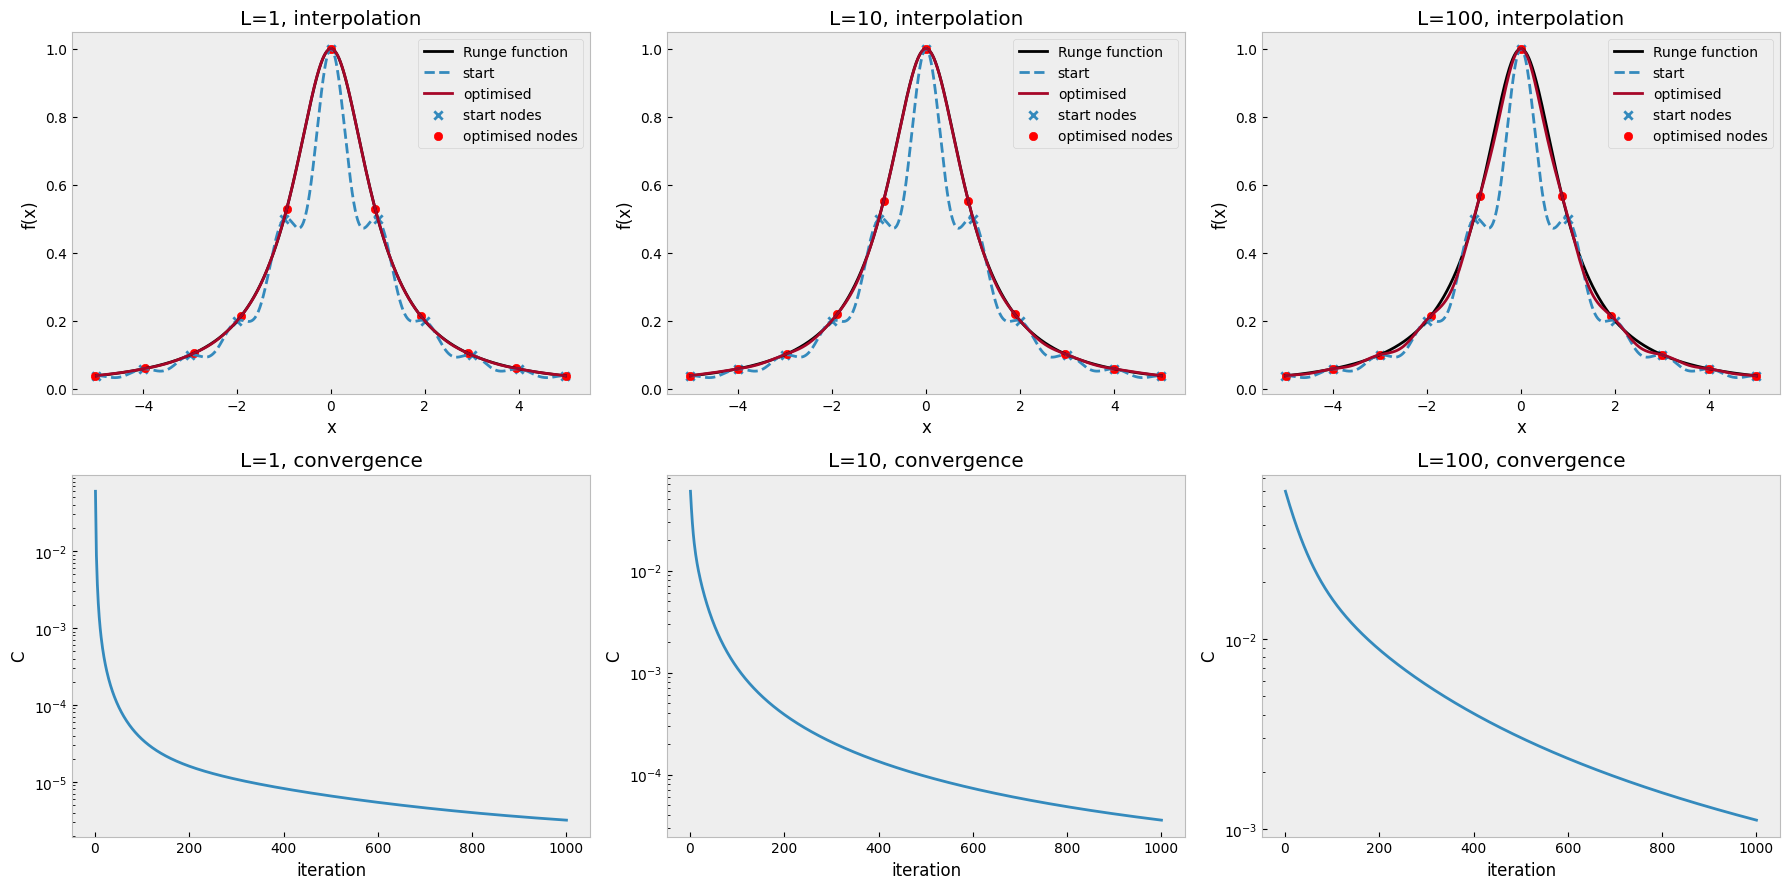

In [2]:
result = optimize_nodes(
    runge_torch,
    -5.0,
    5.0,
    epsilon=2.0,
    n=10,
    L=[1, 10, 100],
    iters=1000,
    L_reset=True
)

When intitializing with $\epsilon = 1$ and equidistant nodes, we see that for every choice of $\mathcal L$ the algorithm seems to find a better set of interpolation values. For higher $\mathcal L$ the algorithm takes a longer time to converge. For longer values of $\mathcal L$ it takes too short steps. In this method we reset $\mathcal L$ to the intial value after each step. It could be advantageus to scale the $\mathcal L $-value when accepting a step. In the next plot we try this.

L=1: cost 5.984e-02 -> 1.920e-06, eps: 2.0 -> 1.2900
L=10: cost 5.984e-02 -> 1.906e-06, eps: 2.0 -> 1.2895
L=100: cost 5.984e-02 -> 1.905e-06, eps: 2.0 -> 1.2894


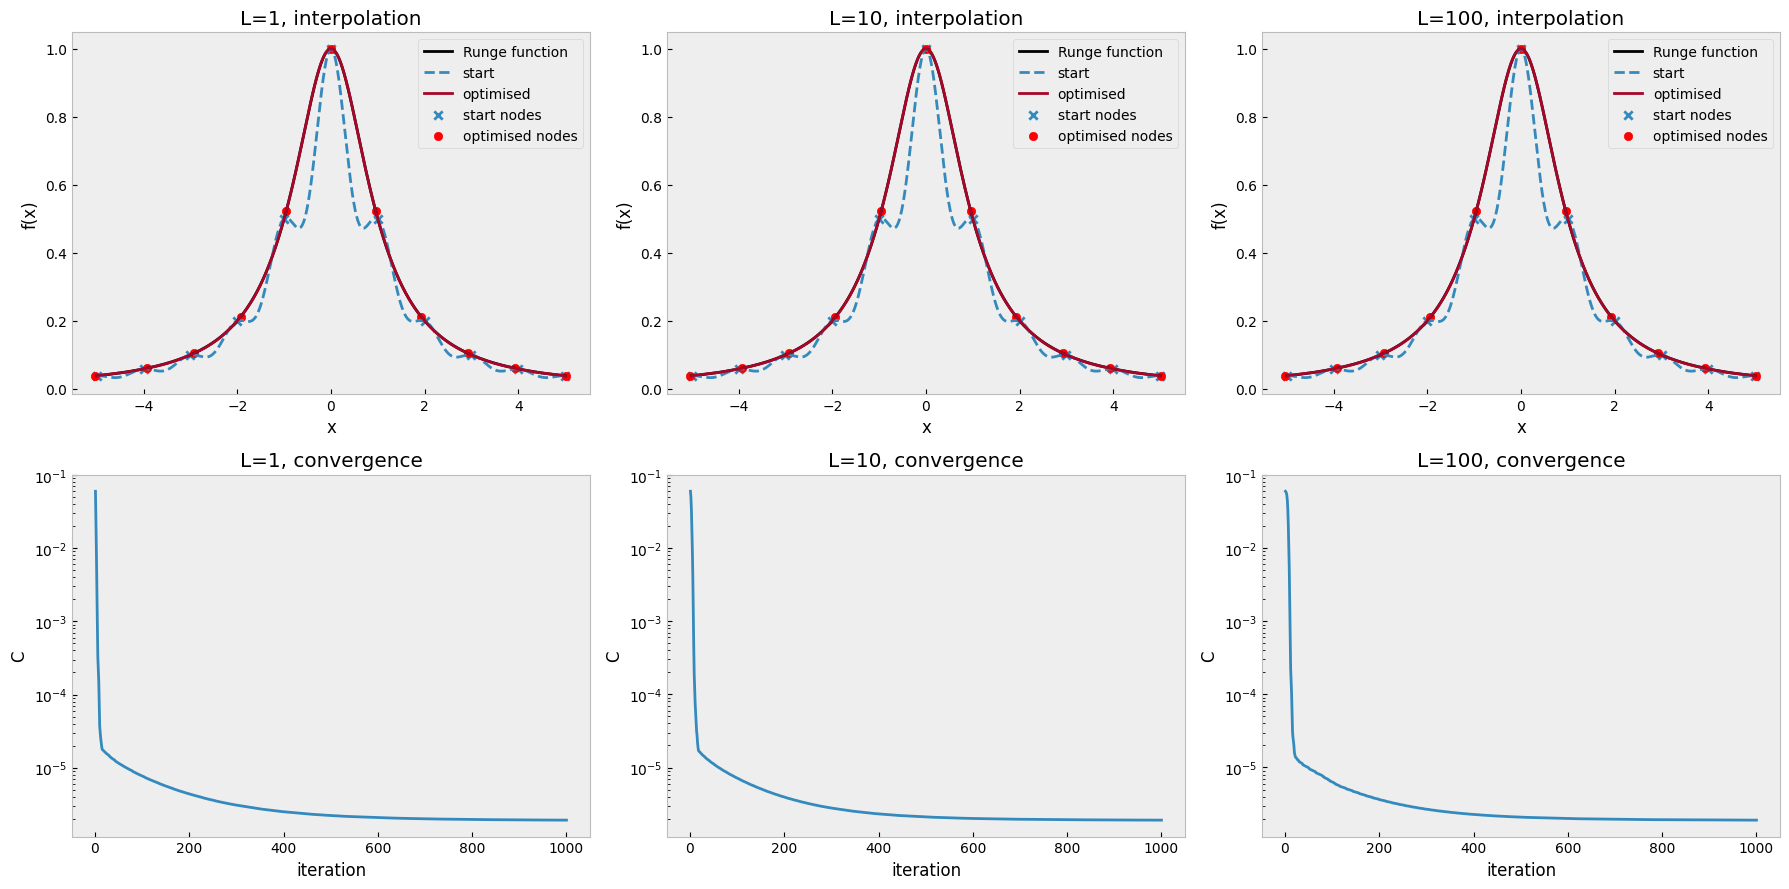

In [3]:
result = results = optimize_nodes(
    runge_torch,
    -5.0,
    5.0,
    epsilon=2.0,
    n=10,
    L=[1, 10, 100],
    iters=1000
)

Not only does it not seem to be a diffrence inbetween the initial values of $\mathcal L$, but the algorithm also converges faster. This is due to our scaling parameters $\bar \rho >1 \text{ and } \underline \rho < 1$ that respectivly increase and decrease $\mathcal L$ when a step is accepted or rejected. So far we have used $\bar \rho = 2\text{ and } \underline \rho = 0.5$ , but let us try to change to $\bar \rho = 1.01\text{ and } \underline \rho = 0.99$. Now the algorithm does less scaling.

L=1: cost 5.984e-02 -> 1.959e-06, eps: 2.0 -> 1.2911
L=10: cost 5.984e-02 -> 2.037e-06, eps: 2.0 -> 1.2928
L=100: cost 5.984e-02 -> 2.338e-06, eps: 2.0 -> 1.2964


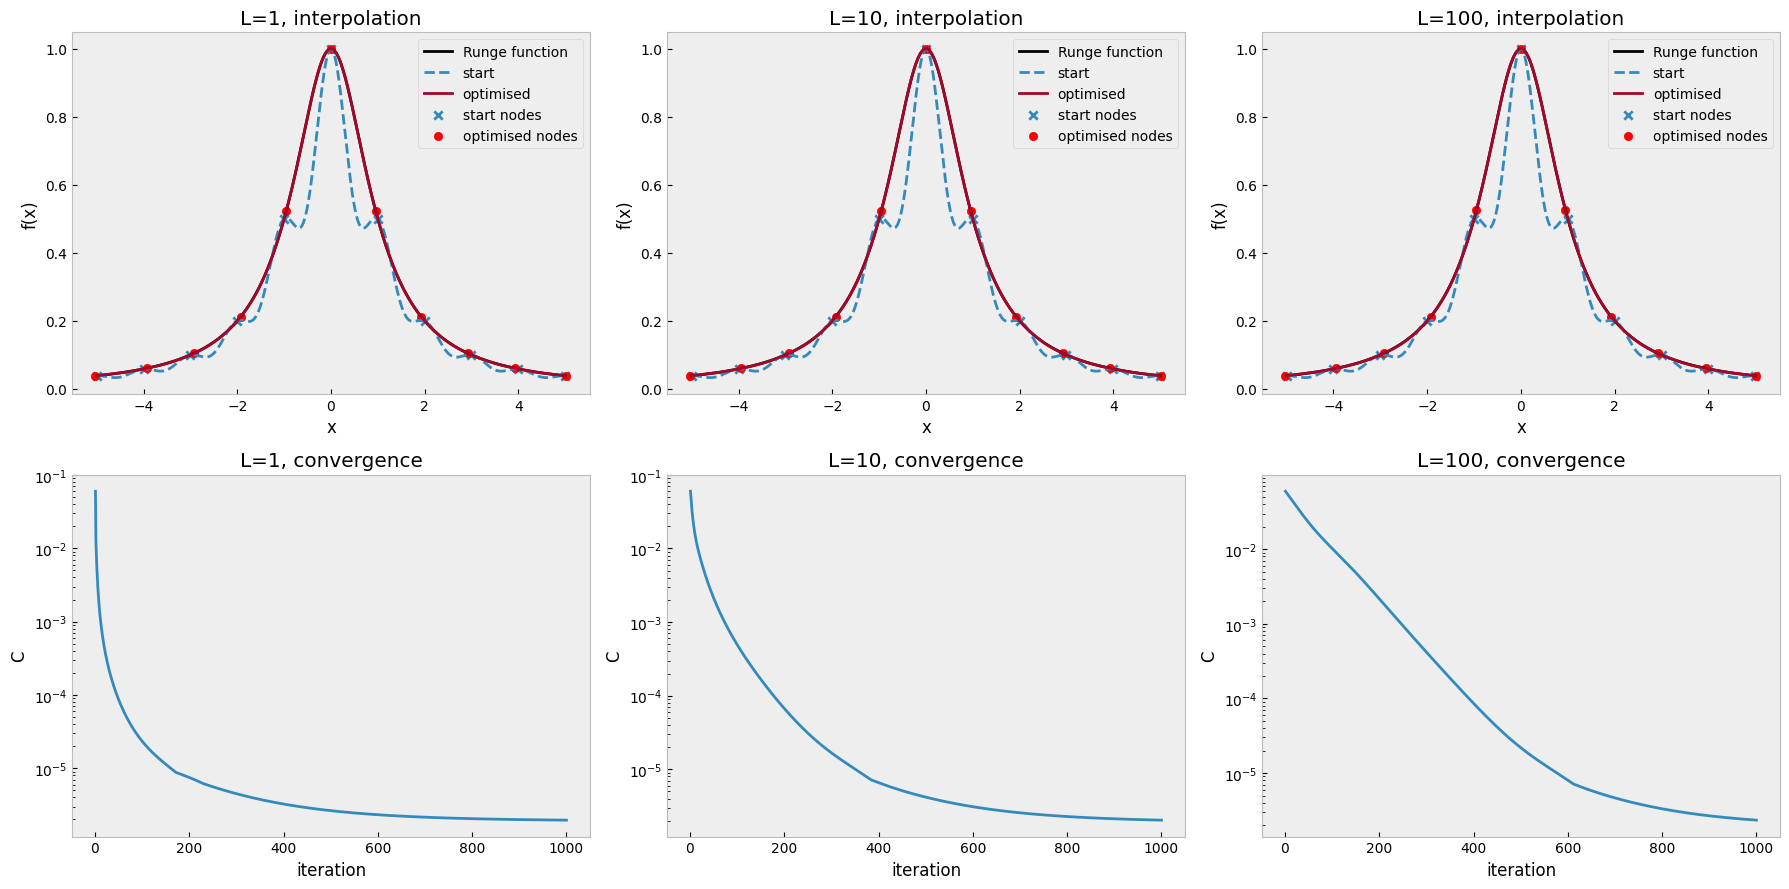

In [4]:
result = results = optimize_nodes(
    runge_torch,
    -5.0,
    5.0,
    epsilon=2.0,
    n=10,
    L=[1, 10, 100],
    iters=1000,
    rho_dec=0.99,
    rho_inc=1.01
)

The same pattern emerges, if we pick too low values for $\bar \rho \text{ and } \underline \rho$ we will loose the stability that comes from the scaling. But what if we instead to a greedier choice with $\bar \rho = 100 \text{ and } \underline \rho = 0.0.1$. This is obviously extreme, but is chosen so that the pattern is visible on the plot.

L=1: cost 5.984e-02 -> 1.889e-06, eps: 2.0 -> 1.2884
L=10: cost 5.984e-02 -> 5.399e-06, eps: 2.0 -> 1.3092
L=100: cost 5.984e-02 -> 1.889e-06, eps: 2.0 -> 1.2884


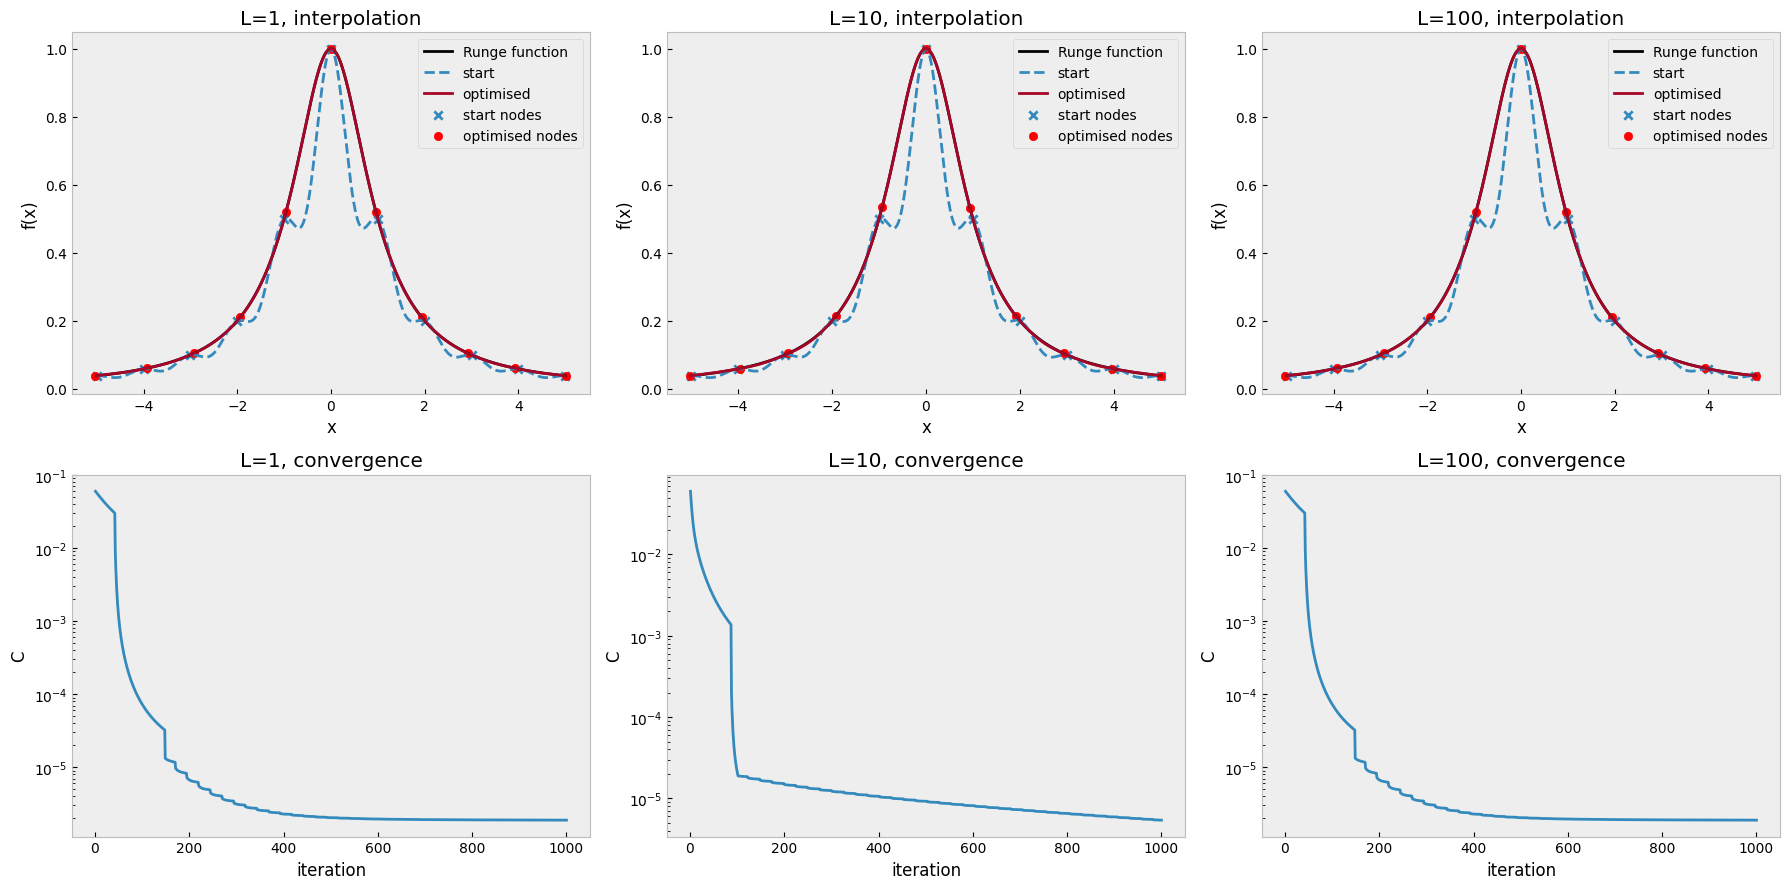

In [5]:
result = results = optimize_nodes(
    runge_torch,
    -5.0,
    5.0,
    epsilon=2.0,
    n=10,
    L=[1, 10, 100],
    iters=1000,
    rho_dec=0.01,
    rho_inc=100
)

Our system still converges, but the convergence is more jagged. It consistenly under and overshoots, making the algorithm more unstable. So we can not be too greedy in our choice of parameters. We may not need to be as precise when it comes to choosing $\epsilon$, but we need to choose acceptable values for $\bar \rho \text{ and } \underline \rho$.

So far we have focused on the `Runge` function for the optimalization. What if we look at $\cos(2\pi x)$? Will the method also work here?

Converged after 2 iterations, |g| = 9.221e-13
L=1.0: cost 1.361e-11 -> 1.826e-13, eps: 1 -> 1.0000


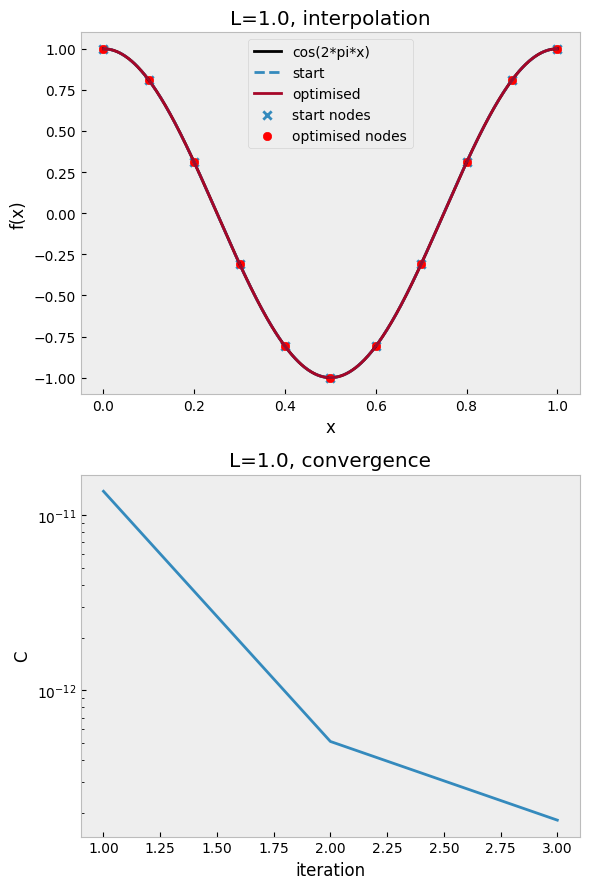

In [6]:
result = optimize_nodes(f_cos_torch, 0, 1.0, epsilon=1, n=10,iters=1000)

The algorithm converges after only 3 iterations. If the size of the gradient is less than $10^{-12}$ we stop the algorithm. The change is just to small to matter. Our cost function that we minimize is not necessarily a convex function, so we are not guaranteed a single ideal case. Showing this is outside the scope of the project, but we can theorize that the start case we have given it is in a local valley. To show this we change intital $\epsilon$ to $4$.

L=1.0: cost 8.023e-08 -> 5.838e-10, eps: 4 -> 4.5240


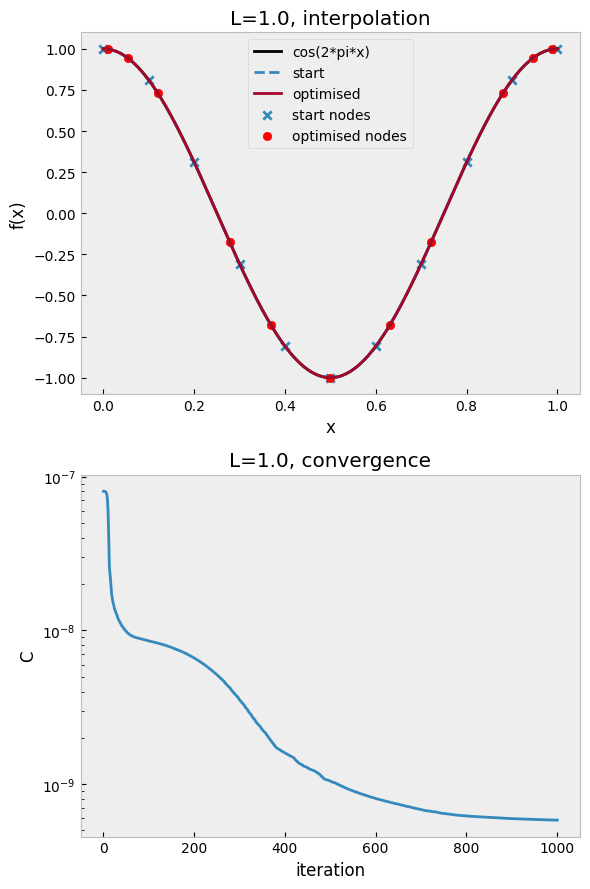

In [7]:
result = optimize_nodes(f_cos_torch, 0, 1.0, epsilon=4, n=10,iters=1000)

Here we do not see the same pattern as before. The speed of convergence is not constant. It seems that the algorithm hits a flat spot that it gets over after $100$ iterations. It could be that the algorithm quits on a flat spot, if we increased the max number of iterations maybe another dip in the cost function is found? We increase to $10,000$ iterations

Converged after 7997 iterations, |g| = 9.897e-13
L=1.0: cost 8.023e-08 -> 5.527e-10, eps: 4 -> 4.5588


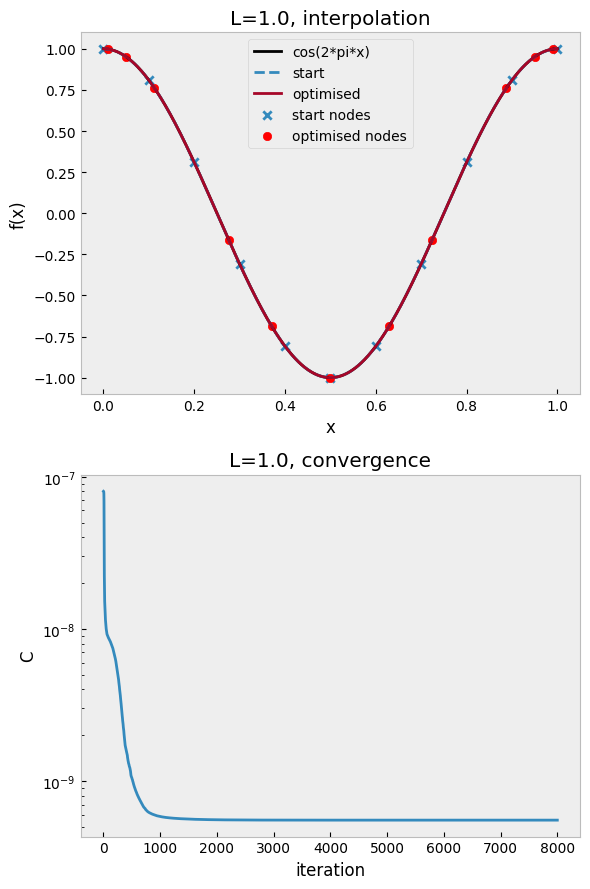

In [8]:
result = optimize_nodes(f_cos_torch, 0, 1.0, epsilon=4, n=10,iters=10000)

The answer is in this case; no. Supporting the valley theory that we will introduce now.

The algorithm increases $\epsilon$ instead, even tough we know that for $\epsilon = 1$ the interpolation is almost perfect. This can be due to 2 different explanations. 1) We know that for smaller values of $\epsilon$ our $M$ matrix becomes ill-conditioned. This could possibly make the gradient unstable and make the algorithm worse. This could also contribute to the quick convergence with $\epsilon =1$. Or 2) this initial value is in another local valley. This is hard to visualize since it will be a $12$-dimensional valley, but we can try by looking at the $1$-dimensional case we have discussed before where we only changed the $\epsilon$ values. We plot again for readability.

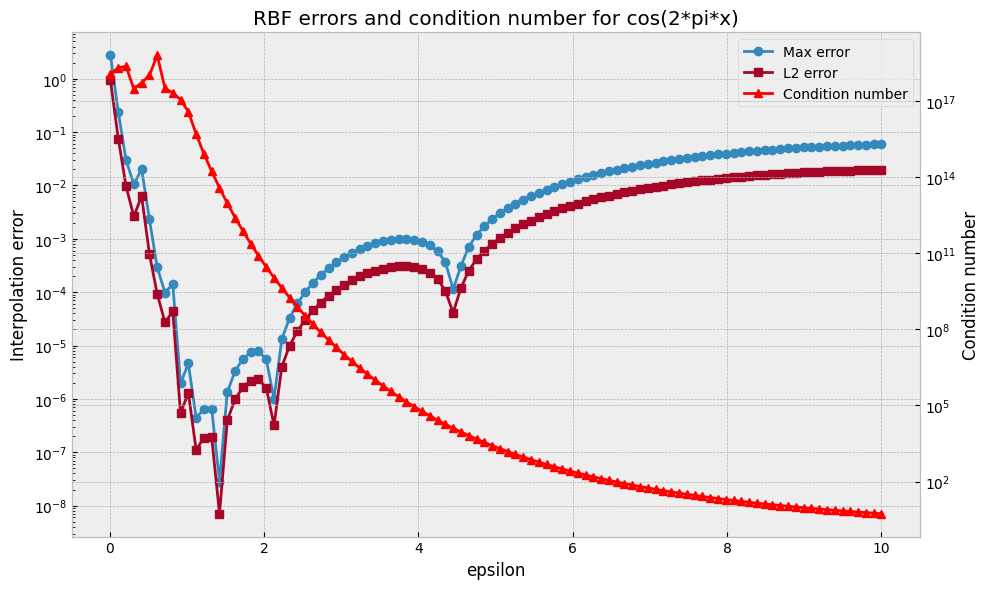

In [9]:
plot_RBF_convergence_condition(f_cos_torch,0,1, 0.01, 10.0, 100, n=10)

This is not entirely accurate, but we se that $\epsilon = 4$ is inside its own valley. $\epsilon$ converges to $4.5240$, which seems to be the same value for epsilon that is inside the valley we see. This highlights a limitation of the algorithm, it can converge to local valleys, not guaranteeing a global optimizer. `*SNAKK OM FORTEGN?*`

While we are on this we can try choosing $\epsilon = 0.1$ to test what happens when we are inside the ill conditioned area.

L=1.0: cost 1.725e-03 -> 9.973e-06, eps: 0.2 -> 0.2269


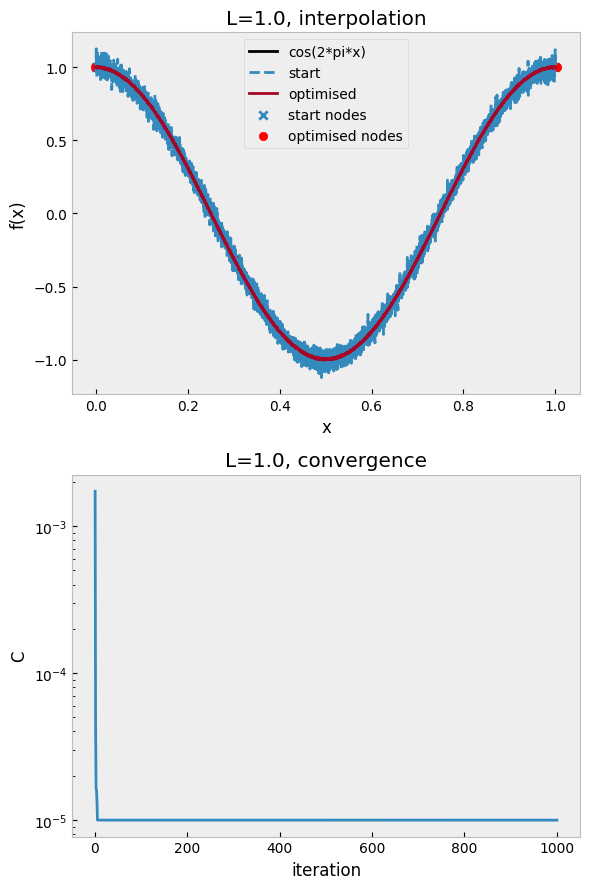

In [10]:
result = optimize_nodes(f_cos_torch, 0, 1.0, epsilon=0.2, n=10,iters=1000)

Now the algorithm also converges, but does not stop. I seems to get stuck somewhere. It could be that the ill-conditioned matrix creates a small local valley that it can not escape. Or that the gradient approximation we do becomes garbage? This is most likely outside the scope of this project, but again highlights the consequences of an ill-conditioned matrix.

We wish to further look at the valley principle. Our last function $e^{3x}\sin(2x)$ did not have the same oscilation effect for choice of $\epsilon$. It could be that we do not get into the same valley effect we found for the $\cos$ function. To start with we plot for just a regular estimate for $\epsilon$.

L=1.0: cost 1.555e-11 -> 1.554e-11, eps: 2.0 -> 2.0000


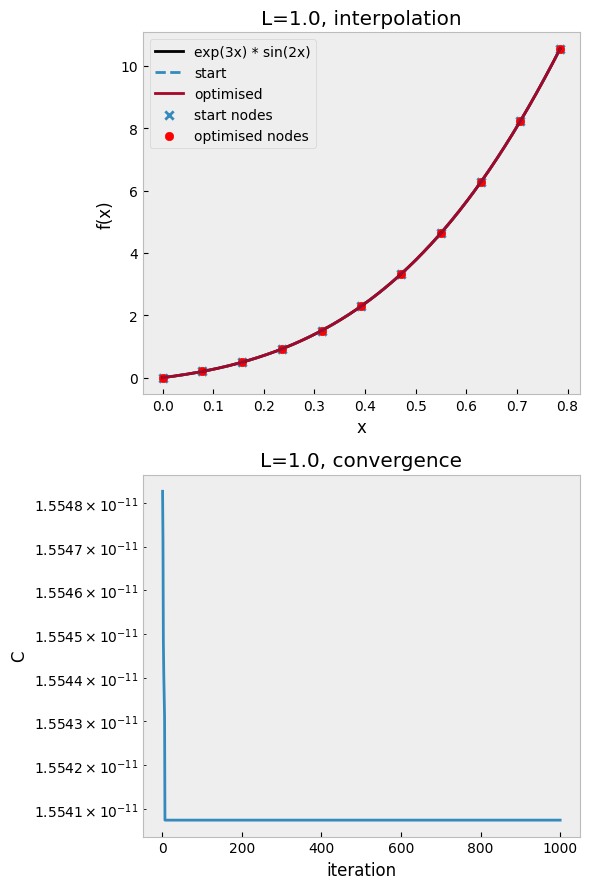

In [11]:
result = optimize_nodes(f_expsin_torch, 0, torch.pi/4, epsilon=2.0, n=10,iters=1000)

We again see the same effect where the initial guess is so good that the algorithm can not find a better one. But what if we start with $\epsilon = 4$? Will we again see the valley effect? We plot the error of $\epsilon$ agin for readability.

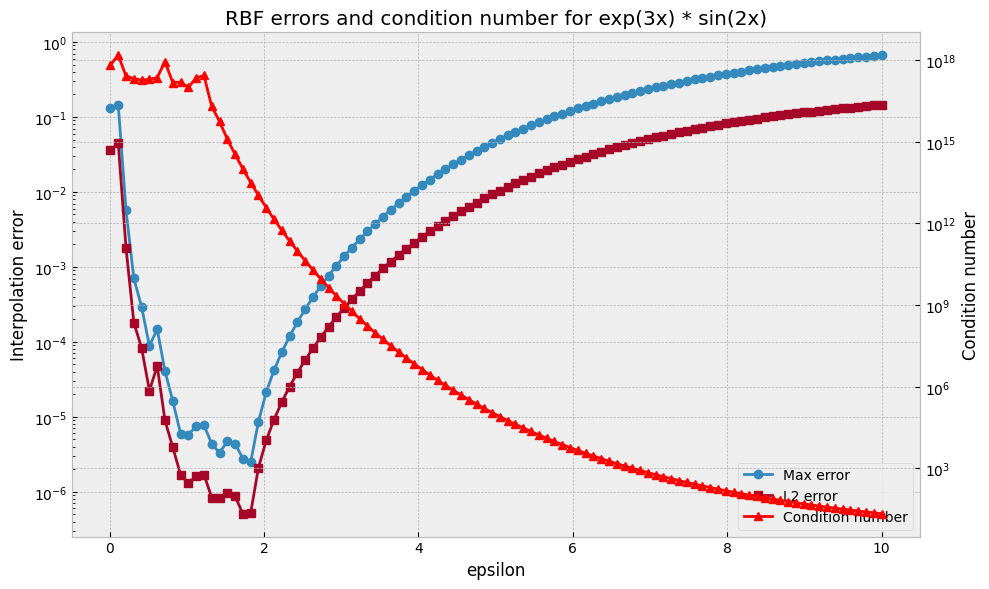

In [12]:
plot_RBF_convergence_condition(f_expsin_torch, 0, torch.pi/4, 0.01, 10.0, 100, n=10)


L=1.0: cost 5.966e-02 -> 6.948e-10, eps: 4.0 -> 1.2976


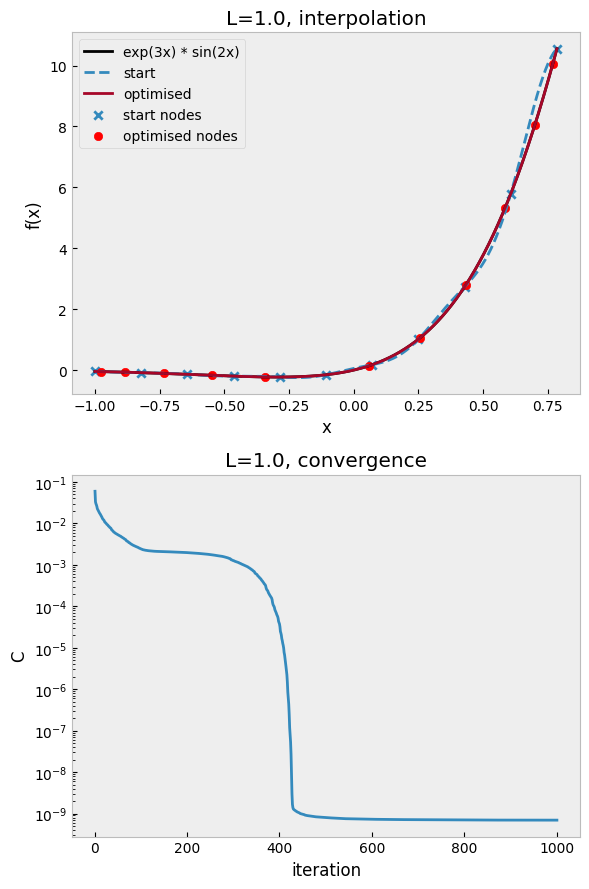

L=1.0: cost 5.966e-02 -> 6.937e-10, eps: 4.0 -> 1.2973


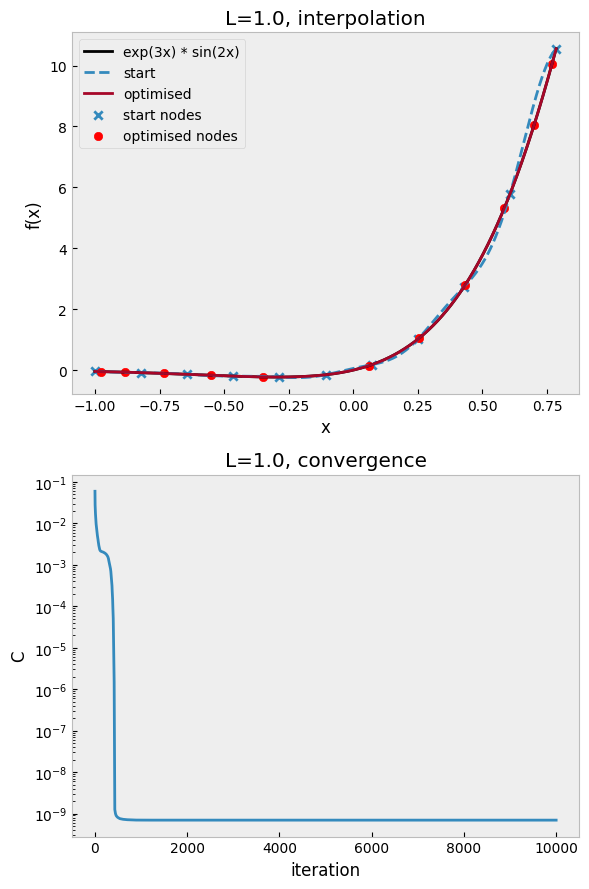

In [13]:
result = optimize_nodes(f_expsin_torch, -1.0, torch.pi/4, epsilon=4.0, n=10,iters=1000)
result = optimize_nodes(f_expsin_torch, -1.0, torch.pi/4, epsilon=4.0, n=10,iters=10000)


The algoritm quickly finds the main valley and stays there. It does not get stuck in any valleys along the way. So it is important to take this into consideration when choosing an initial value. But this value for $\epsilon$ is on the steep part of the graph. What if we picked a a value that has a smaller slope. Say $\epsilon = 10 $. Will we still get to our ideal condition?

L=1.0: cost 9.456e-02 -> 1.849e-02, eps: 10 -> 9.9935


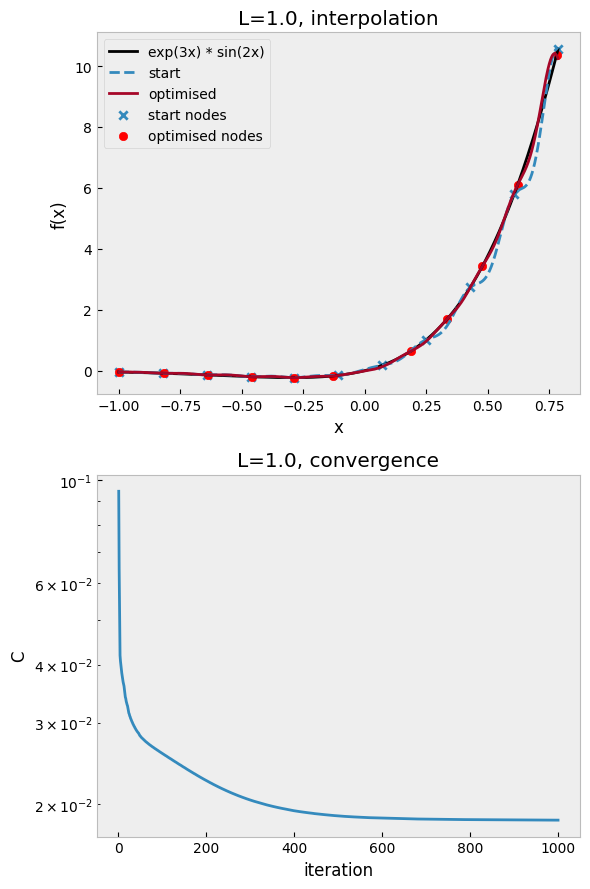

L=1.0: cost 9.456e-02 -> 1.818e-02, eps: 10 -> 10.0761


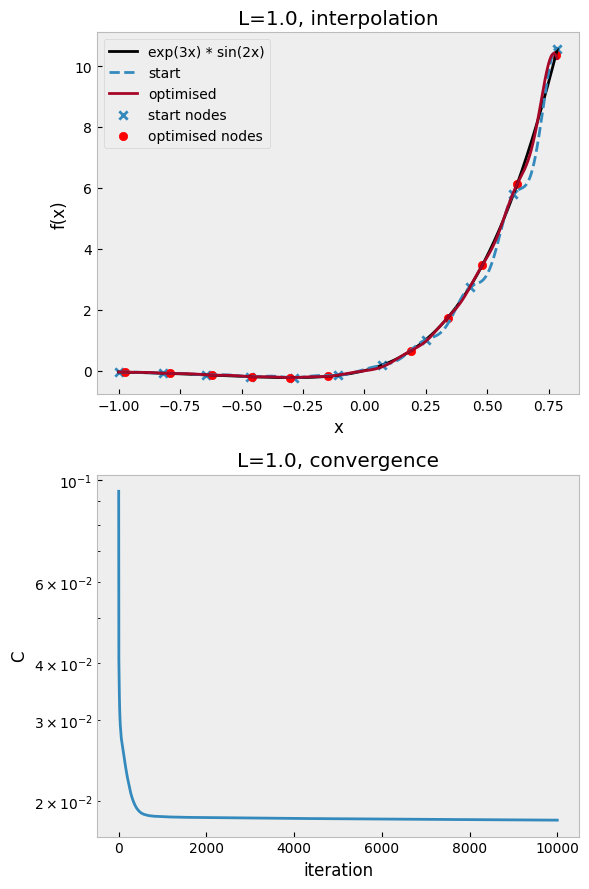

L=1.0: cost 9.456e-02 -> 1.756e-02, eps: 10 -> 10.4524


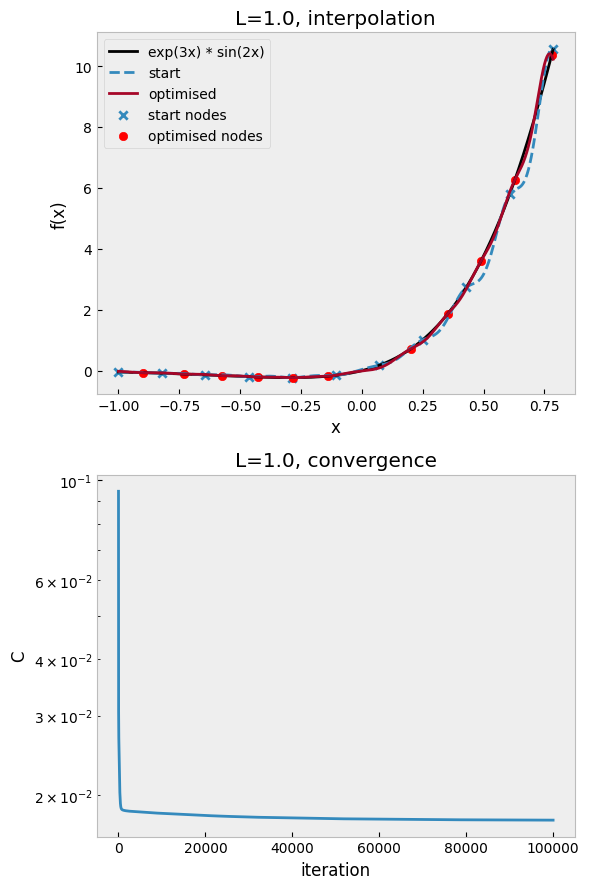

In [14]:
result = optimize_nodes(f_expsin_torch, -1.0, torch.pi/4, epsilon=10, n=10,iters=1000)
result = optimize_nodes(f_expsin_torch, -1.0, torch.pi/4, epsilon=10, n=10,iters=10000)
result = optimize_nodes(f_expsin_torch, -1.0, torch.pi/4, epsilon=10, n=10,iters=100000)

The answer is no. It seems to get stuck on the flat part of the slope. Our main theory is that this is due to the parameter $\mathcal L$ dictating how big of a step we can take on both $x$ and $\epsilon$. When starting on a flat part the epsilon will do very small steps due to the gradient being so small. In the mean time the nodes will find their ideal distribution and settle for this. After finding the ideal node distribution the algorithm will only accept steps that have enough improvement. Moving too far away with the nodes will give a worse solution, so large steps are not accepted. Since the gradient for $\epsilon$ is so small it will never actually move in any meaningfull way. A fix for this could be to introduce seperate parameters for the nodes and $\epsilon$, but this is moving too far outside what we consider the scope of the project.